In [19]:
import numpy as np
from qiskit.circuit import QuantumCircuit, ParameterVector
from qiskit_machine_learning.state_fidelities import ComputeUncompute
from qiskit_machine_learning.kernels import (
    FidelityQuantumKernel,
)
import matplotlib as mpl
import matplotlib.pyplot as plt
from gpjax.kernels.base import AbstractKernel
from gpjax.kernels.computations import DenseKernelComputation
from qiskit.quantum_info import Statevector
import torch
torch.set_default_dtype(torch.float64)
cols = mpl.rcParams["axes.prop_cycle"].by_key()["color"]

### Load data

In [20]:
# training data
n_train = 25
X_train = np.linspace(-0.95, 0.95, n_train).reshape(-1, 1)
y_train = np.sin(3 * X_train[:, 0]) + 0.1 * np.random.randn(n_train)

# test inputs
X_test = np.linspace(-1.0, 1.0, 200).reshape(-1, 1)

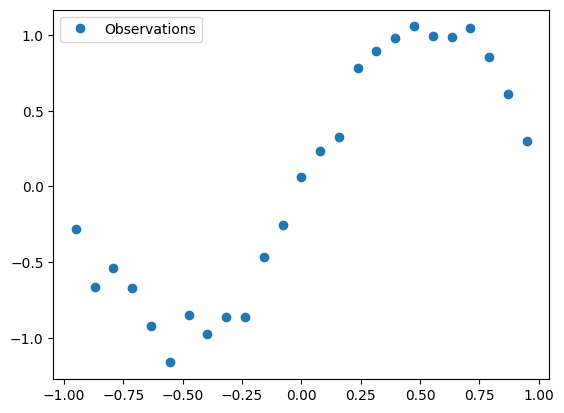

In [21]:
fig, ax = plt.subplots()
ax.plot(X_train, y_train, "o", label="Observations", color=cols[0])
ax.legend(loc="best")

### Define the frature map

In [22]:
def chebyshev_feature_map_vector(
    n_qubits=4,
    n_layers=1,
    entanglement="ring",
    name="ChebyshevInspiredFM",
):
    alpha = ParameterVector("alpha", n_qubits)
    qc = QuantumCircuit(n_qubits, name=name)

    theta_blocks = []

    if entanglement == "ring":
        edges = [(i, (i + 1) % n_qubits) for i in range(n_qubits)]
    elif entanglement == "linear":
        edges = [(i, i + 1) for i in range(n_qubits - 1)]
    else:
        raise ValueError("entanglement must be 'ring' or 'linear'")

    n_ent = len(edges)

    for layer in range(n_layers):
        theta = ParameterVector(f"theta_{layer}", n_qubits + n_ent)
        theta_blocks.append(theta)

        # Local trainable Ry
        for i in range(n_qubits):
            qc.ry(theta[i], i)

        # Data-dependent Rx(theta_i * alpha_i)
        for i in range(n_qubits):
            qc.rx(theta[i] * alpha[i], i)

        # Entanglers
        for j, (c, t) in enumerate(edges):
            qc.crz(theta[n_qubits + j], c, t)

        # Final trainable Ry
        for i in range(n_qubits):
            qc.ry(theta[i], i)

    return qc, alpha, theta_blocks

In [23]:
# Define a function to bind the parameters of the feature map given an input vector x and the theta values for each layer
def make_bound_feature_map(
    x,
    feature_map,
    alpha_params,
    theta_blocks,
    theta_values,
):
    """
    x: array shape (n_qubits,)
    theta_values: list of arrays, one per layer
    """
    x = np.asarray(x, dtype=float)
    x = np.clip(x, -1.0, 1.0)
    alpha_values = np.arccos(x)

    bind_dict = {}

    for i, p in enumerate(alpha_params):
        bind_dict[p] = float(alpha_values[i])

    for layer, theta in enumerate(theta_blocks):
        vals = theta_values[layer]
        for j, p in enumerate(theta):
            bind_dict[p] = float(vals[j])

    return feature_map.assign_parameters(bind_dict, inplace=False)

In [24]:
def fidelity_from_circuits(qc_x, qc_y):
    psi_x = Statevector.from_instruction(qc_x)
    psi_y = Statevector.from_instruction(qc_y)
    overlap = np.vdot(psi_x.data, psi_y.data)
    return float(np.abs(overlap) ** 2)

### Gram matrix computation

In [25]:
def quantum_kernel_matrix(
    X1,
    X2,
    feature_map,
    alpha_params,
    theta_blocks,
    theta_values,
    symmetric=False,
):
    n1 = len(X1)
    n2 = len(X2)
    K = np.zeros((n1, n2), dtype=float)

    bound_1 = [
        make_bound_feature_map(x, feature_map, alpha_params, theta_blocks, theta_values)
        for x in X1
    ]
    bound_2 = bound_1 if symmetric else [
        make_bound_feature_map(x, feature_map, alpha_params, theta_blocks, theta_values)
        for x in X2
    ]

    for i in range(n1):
        j_start = i if symmetric else 0
        for j in range(j_start, n2):
            kij = fidelity_from_circuits(bound_1[i], bound_2[j])
            K[i, j] = kij
            if symmetric:
                K[j, i] = kij

    return K

### Instantiate the feature map

In [58]:
n_qubits = 4
n_layers = 2
entanglement = "linear"

feature_map, alpha_params, theta_blocks = chebyshev_feature_map_vector(
    n_qubits=n_qubits,
    n_layers=n_layers,
    entanglement=entanglement,
)

# fixed theta for first prototype
theta_values = []
for theta in theta_blocks:
    theta_values.append(np.full(len(theta), 0.7))

In [59]:
def repeat_scalar_to_qubits(X, n_qubits):
    """
    X: shape (N, 1)
    returns: shape (N, n_qubits)
    """
    X = np.asarray(X, dtype=float)
    if X.ndim != 2 or X.shape[1] != 1:
        raise ValueError("Expected X of shape (N, 1) for scalar inputs.")
    return np.repeat(X, repeats=n_qubits, axis=1)

In [60]:
X_train_q = repeat_scalar_to_qubits(X_train, n_qubits=n_qubits)
X_test_q  = repeat_scalar_to_qubits(X_test, n_qubits=n_qubits)

K_xx = quantum_kernel_matrix(
    X_train_q,
    X_train_q,
    feature_map,
    alpha_params,
    theta_blocks,
    theta_values,
    symmetric=True,
)

K_tx = quantum_kernel_matrix(
    X_test_q,
    X_train_q,
    feature_map,
    alpha_params,
    theta_blocks,
    theta_values,
    symmetric=False,
)

K_tt = quantum_kernel_matrix(
    X_test_q,
    X_test_q,
    feature_map,
    alpha_params,
    theta_blocks,
    theta_values,
    symmetric=True,
)

In [61]:
def gp_posterior_from_kernel_matrices(
    K_xx,
    K_tx,
    K_tt,
    y_train,
    noise_variance=1e-4,
    jitter=1e-8,
):
    """
    Gaussian Process Regression posterior from precomputed kernel matrices.

    Parameters
    ----------
    K_xx : array-like, shape (n_train, n_train)
        Train-train kernel matrix.
    K_tx : array-like, shape (n_test, n_train)
        Test-train kernel matrix.
    K_tt : array-like, shape (n_test, n_test)
        Test-test kernel matrix.
    y_train : array-like, shape (n_train,)
        Training targets.
    noise_variance : float
        Observation noise variance sigma_n^2.
    jitter : float
        Small diagonal stabilization term.

    Returns
    -------
    pred_mean : torch.Tensor, shape (n_test,)
    pred_cov : torch.Tensor, shape (n_test, n_test)
    pred_var : torch.Tensor, shape (n_test,)
    """
    K_xx = torch.as_tensor(K_xx)
    K_tx = torch.as_tensor(K_tx)
    K_tt = torch.as_tensor(K_tt)
    y_train = torch.as_tensor(y_train).reshape(-1)

    n_train = K_xx.shape[0]
    I = torch.eye(n_train, dtype=K_xx.dtype, device=K_xx.device)

    Ky = K_xx + (noise_variance + jitter) * I

    # Cholesky factorization: Ky = L L^T
    L = torch.linalg.cholesky(Ky)

    # alpha = Ky^{-1} y via triangular solves
    alpha = torch.cholesky_solve(y_train[:, None], L).squeeze(-1)

    # posterior mean: K_*X alpha
    pred_mean = K_tx @ alpha

    # posterior covariance: K_** - K_*X Ky^{-1} K_X*
    V = torch.linalg.solve_triangular(L, K_tx.T, upper=False)
    pred_cov = K_tt - V.T @ V

    pred_var = torch.diag(pred_cov).clamp_min(0.0)

    return pred_mean, pred_cov, pred_var

In [62]:
pred_mean, pred_cov, pred_var = gp_posterior_from_kernel_matrices(
    K_xx=K_xx,
    K_tx=K_tx,
    K_tt=K_tt,
    y_train=y_train,
    noise_variance=0.05**2,
)

pred_std = torch.sqrt(pred_var)

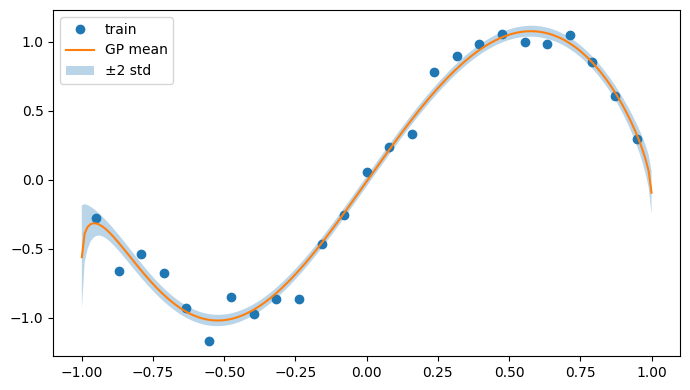

In [63]:
plt.figure(figsize=(7, 4))
plt.plot(X_train[:, 0], y_train, "o", label="train")
plt.plot(X_test[:, 0], pred_mean.numpy(), label="GP mean")
plt.fill_between(
    X_test[:, 0],
    (pred_mean - 2 * pred_std).numpy(),
    (pred_mean + 2 * pred_std).numpy(),
    alpha=0.3,
    label="±2 std",
)
plt.legend()
plt.tight_layout()
plt.show()